GenAI (GPT-5 and GEMINI) has been used to do this project as a helping tool. This project has been created only by Roberto Punzano, without the help of any other human.

## 0. Importing Libraries and Dataset

In [ ]:
!python -m spacy download es_core_news_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.0/568.0 MB 803.4 kB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import pandas as pd
import numpy as np
import spacy #for linguistic data curation
import json #saving files
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer #DitilBERT and fine-tuning
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt   #visualizing plots
import seaborn as sns   #prettier plotting
import torch as tc  #tensor computation and GPU handling
import numpy as np
from html import unescape #to process text from HTML
from datasets import load_dataset   #creating a DataSet object
from huggingface_hub import login
login()

In [ ]:
#Loading the dataset and filtring it

dataset_full = load_dataset("clapAI/MultiLingualSentiment", split="train")  #we load the full dataset
dataset_es = dataset_full.filter(lambda x: x['language'] == 'es')   #we filter the Spanish dataset
print(dataset_es)
df = dataset_es.to_pandas()[['label', 'text']]

Dataset({
    features: ['text', 'label', 'source', 'domain', 'language'],
    num_rows: 178434
})


## 1. Creating the Training, Validation and Test Sets

In [ ]:
dataset_small = dataset_es.shuffle(seed=42).select(range(5000))

dataset_train_test = dataset_small.train_test_split(test_size=0.2, seed=42)  #splitting the first set into train (80%) and provisional test (20%)
dataset_dev_test = dataset_train_test['test'].train_test_split(test_size=0.5, seed=42)

#Final DataSets
train_set = dataset_train_test['train']
dev_set = dataset_dev_test['train']
test_set = dataset_dev_test['test']

print(f"Train: {len(train_set)}, Dev: {len(dev_set)}, Test: {len(test_set)}")

Train: 4000, Dev: 500, Test: 500


In [ ]:
label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

def encode_labels(example):
  """This function encodes negative, positive and neutral into digits for data processing"""
    example["label"] = label2id[example["label"]]
    return example

train_set = train_set.map(encode_labels)
dev_set = dev_set.map(encode_labels)
test_set = test_set.map(encode_labels)

## 2. Processing the text with spaCy (curating linguistic data)

In [ ]:
#Loading spaCy model
nlp = spacy.load("es_core_news_lg", disable=["ner", "parser"])

In [ ]:
def data_curation(text):
    if not text: return "neutral"

    text = unescape(str(text))  #HTML text cleaning
    text = text.lower()   #we lowercase everything to ease the process

    doc = nlp(text)
    final_tokens = []

    negations = {"no", "ni", "nunca", "jamás", "tampoco", "nada", "pero", "aunque", "sin"}

    for token in doc:
        if token.lower_ in negations:
            final_tokens.append(token.lower_)   #we keep negations (they are important for sentiment analysis!)

        elif token.pos_ == "ADJ":               #we keep adjectives
            final_tokens.append(token.text)

        elif token.pos_ in ["VERB", "NOUN"]:
            final_tokens.append(token.lemma_)   #we lemmatize verbs and nouns

        else:
            final_tokens.append(token.text)     #we keep the rest

    return " ".join(final_tokens)

In [ ]:
def prepare_dataset(example):
    """This function prepares the dataset for cleaning"""
    example["text"] = data_curation(example["text"])
    example["labels"] = int(example["label"])

    return example

In [ ]:
train_set_curated = train_set.map(prepare_dataset)
dev_set_curated = dev_set.map(prepare_dataset)
test_set_curated = test_set.map(prepare_dataset)

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [ ]:
print("ORIGINAL:", train_set[0]["text"])
print("CURATED: ", train_set_curated[0]["text"])

ORIGINAL: Se parece muhco a su original GSHOCK
Es muy parecido a los GSHOCK de casio, el materiel es claramente peor pero sin tocarlo y sin ver el nombre muy similares.
CURATED:  se parecer muhcir a su original gshock 
 es muy parecido a los gshock de casio , el materiel es claramente peor pero sin tocar él y sin ver el nombre muy similares .


## 3. Tokenizer and Model Configuration

In [ ]:
#Loading the Tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-multilingual-cased")
sentence = "Buena compra Tiene el tamaño perfecto. Fácil de limpiar y su uso doble es genial."
tokens_sentence = tokenizer(sentence)
print(tokens_sentence)

{'input_ids': [101, 71436, 50753, 32005, 10125, 29098, 43477, 10133, 119, 143, 60074, 10161, 10104, 11614, 58150, 10129, 193, 10198, 13829, 29783, 10196, 107282, 10415, 119, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [ ]:
def tokenize(batch):
    """This function tokenizes and regulates sentences (by truncating them or adding paddings [0])"""

    textos = [str(text) for text in batch['text']] #in case of NaN, converting to string so that the tokenizer can read it

    return tokenizer(
        textos,
        padding='max_length',
        truncation=True,
        max_length=128
    )

sentence = "Buena compra Tiene el tamaño perfecto. Fácil de limpiar y su uso doble es genial."
tokenized_example = tokenize({'text': [sentence]})

print(f"Sentence: {sentence}")
print(f"Tokens: {tokenized_example.keys()}")

Sentence: Buena compra Tiene el tamaño perfecto. Fácil de limpiar y su uso doble es genial.
Tokens: KeysView({'input_ids': [[101, 71436, 50753, 32005, 10125, 29098, 43477, 10133, 119, 143, 60074, 10161, 10104, 11614, 58150, 10129, 193, 10198, 13829, 29783, 10196, 107282, 10415, 119, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
#Tokenizing all sets with the .map() function from Hugging Face datasets library
tokenized_train = train_set_curated.map(tokenize, batched=True)
tokenized_dev = dev_set_curated.map(tokenize, batched=True)
tokenized_test = test_set_curated.map(tokenize, batched=True)

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [ ]:
#Transforming tokenized datasets into PyTorch tensors
tokenized_train.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
tokenized_dev.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
tokenized_test.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

In [ ]:
print(tokenized_train[0]['labels'])

tensor(2)


In [ ]:
#Structure of the datasets
print(tokenized_train)
print(tokenized_dev)

Dataset({
    features: ['text', 'label', 'source', 'domain', 'language', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 4000
})
Dataset({
    features: ['text', 'label', 'source', 'domain', 'language', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 500
})


In [ ]:
#Loading a Sequence Classification Pretrained Model based on DistilBERT
hs_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-multilingual-cased",
    num_labels=3    #Three Class Classification
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## 4. Model Performance in Training and Validation Sets

In [ ]:
#Initializing Arguments for Settings for the Training Model
training_args = TrainingArguments(
    per_device_train_batch_size=8,   #Taking batches from 16 to 16 (optimized for GPU memory and training stability)
    gradient_accumulation_steps=2,
    learning_rate=2e-5,   #Gradient Descent Steps
    num_train_epochs=3,   #Three epochs to avoid Overfitting
    eval_strategy="epoch",
    logging_steps=50,  #Log Training Metrics every 50 Steps
    fp16=True,     #Speed Up Training and GPU Optimization
    save_strategy="epoch",
    load_best_model_at_end=True, #This takes the best epoch for the model (avoiding imprecision or overfitting)
    metric_for_best_model="eval_loss", #Choosing loss instead of accuracy to be more precise
    save_total_limit=2    #Limiting 2 Savings
)

In [ ]:
#Fitting the Train Set: Connecting the model, the data and the training configuration
trainer = Trainer(
    model=hs_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_dev,
)

In [ ]:
#Showing GPU
print(tc.cuda.is_available())
print(tc.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
#Training the Model

trainer.train()

Epoch,Training Loss,Validation Loss
1,1.394990,0.651432
2,1.092301,0.648327
3,0.961295,0.647681


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=750, training_loss=1.2335099843343098, metrics={'train_runtime': 174.7324, 'train_samples_per_second': 68.676, 'train_steps_per_second': 4.292, 'total_flos': 397409283072000.0, 'train_loss': 1.2335099843343098, 'epoch': 3.0})

Metrics for TRAIN set
Precision: 0.813
Recall:    0.796
F1:        0.801
Confusion Matrix:
[[1511   86   16]
 [ 227  427  136]
 [  26  117 1454]]


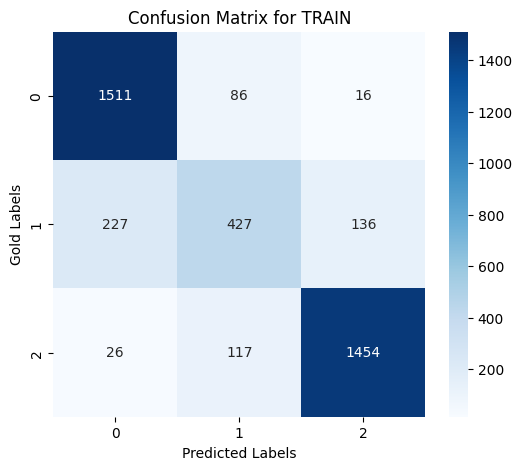

Metrics for DEV set
Precision: 0.682
Recall:    0.681
F1:        0.681
Confusion Matrix:
[[171  23   6]
 [ 34  34  23]
 [ 12  27 170]]


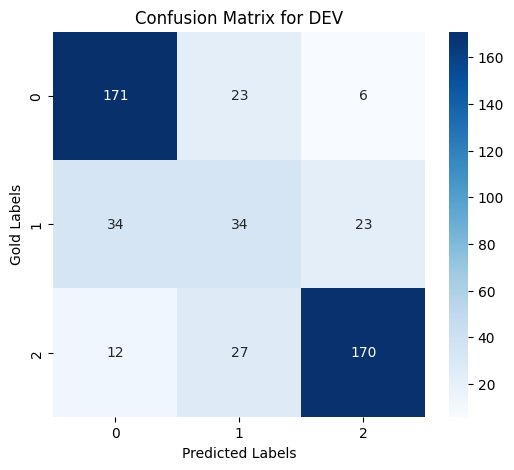

In [ ]:
#Computing and saving Metrics
def evaluate_model(trainer, tokenized_dataset, dataset_name="dev", save_path=None):
    """
    Computes precision, recall, F1, and confusion matrix
    for a given dataset using the HuggingFace Trainer predictions.
    """
    #Getting model predictions
    predictions_output = trainer.predict(tokenized_dataset)

    y_pred = predictions_output.predictions.argmax(axis=1)  #predicted labels
    y_gold = predictions_output.label_ids   #true labels

    #Computing metrics
    precision = precision_score(y_gold, y_pred, average='macro')  #average macro takes the mean of all rates
    recall = recall_score(y_gold, y_pred, average='macro')
    f1 = f1_score(y_gold, y_pred, average='macro')
    cm = confusion_matrix(y_gold, y_pred)

    #Printing metrics
    print(f"Metrics for {dataset_name.upper()} set")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1:        {f1:.3f}")
    print("Confusion Matrix:")
    print(cm)

    #Plotting confusion matrix
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted Labels')
    plt.ylabel('Gold Labels')
    plt.title(f'Confusion Matrix for {dataset_name.upper()}')
    plt.show()

    return precision, recall, f1, cm

#Running the function for train and dev sets
train_metrics = evaluate_model(trainer, tokenized_train, dataset_name="train", save_path="train_metrics.json")
dev_metrics   = evaluate_model(trainer, tokenized_dev, dataset_name="dev", save_path="dev_metrics.json")


## 5. Test Set

In [ ]:
# Running the Test Set
predictions_output = trainer.predict(tokenized_test)

In [ ]:
#Get predicted classes
y_pred = np.argmax(predictions_output.predictions, axis=1)
y_gold = predictions_output.label_ids

print("Predictions:", y_pred)
print("Gold labels:", y_gold)

#Confusion matrix
cm = confusion_matrix(y_gold, y_pred)
print("Confusion matrix:\n", cm)

#Compute metrics
precision = precision_score(y_gold, y_pred, average='macro')
recall = recall_score(y_gold, y_pred, average='macro')
f1 = f1_score(y_gold, y_pred, average='macro')

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1:        {f1:.3f}")

Predictions: [0 1 1 2 2 0 2 2 0 2 0 0 2 2 2 0 2 2 0 2 0 2 1 2 2 1 2 0 1 2 2 0 2 0 0 0 2
 0 0 2 1 0 2 0 2 2 2 1 1 2 0 2 2 1 2 2 2 0 2 2 0 0 2 2 2 1 0 2 2 0 2 0 0 0
 1 0 1 0 2 0 0 0 2 1 2 2 1 1 0 0 0 2 1 2 2 0 2 0 2 2 2 2 0 2 0 1 1 0 2 0 0
 1 0 2 0 0 0 0 2 2 2 0 1 0 1 2 0 1 2 0 2 2 0 2 0 2 0 0 0 2 2 0 2 0 2 0 0 0
 2 2 2 2 0 0 1 1 0 2 2 2 0 0 0 0 2 2 2 2 0 2 2 2 0 2 1 0 2 0 1 0 2 0 0 2 0
 1 0 2 2 0 0 2 0 2 1 0 2 0 0 0 0 2 0 0 0 2 0 0 0 2 0 2 0 0 2 2 0 2 0 2 0 2
 0 1 0 0 2 2 0 2 0 1 1 0 2 0 2 0 2 0 2 2 0 2 2 0 2 0 2 0 0 0 2 2 1 0 2 2 0
 1 0 1 2 0 1 1 2 0 0 0 1 1 2 2 0 2 0 2 2 2 2 0 0 0 2 0 2 1 0 0 1 2 2 1 0 0
 2 0 0 2 2 0 2 1 0 0 0 1 0 2 2 2 1 0 2 2 0 2 1 0 0 0 0 0 0 2 0 2 0 1 2 1 2
 2 0 0 0 2 2 0 2 0 0 2 0 2 0 0 0 0 2 2 0 2 0 0 2 0 0 1 0 0 2 2 0 0 0 0 1 0
 0 2 1 2 1 1 0 1 2 1 0 1 2 0 1 2 2 2 0 1 0 1 0 0 0 2 2 1 0 0 2 0 0 0 2 2 0
 2 0 0 0 2 2 2 0 1 0 2 2 0 0 2 0 1 2 2 0 2 2 2 0 2 0 2 0 2 2 2 2 0 0 0 2 0
 1 0 1 2 2 2 0 2 1 0 0 2 0 0 1 0 2 0 1 2 0 2 1 2 2 2 1 0 0 0 2 0 2 0 0 2 2
 2 2 2 2 0 2

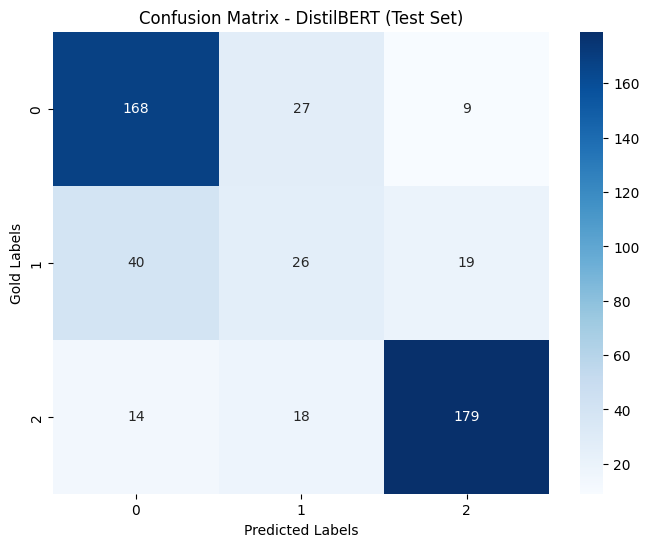

In [ ]:
# Visualizing Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('Gold Labels')
plt.title('Confusion Matrix - DistilBERT (Test Set)')
plt.show()